# **Setup**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import time

PROC = '/content/drive/MyDrive/ProyectoPension65/processed'
RAW = '/content/drive/MyDrive/ProyectoPension65/raw'

Mounted at /content/drive


# **Carga del dataset**

In [3]:
nivel_micro = pd.read_csv(f'{PROC}/nivel_micro.csv', dtype={'CONGLOME': str, 'VIVIENDA': str, 'HOGAR': str, 'UBIGEO': str})
nivel_macro = pd.read_csv(f'{PROC}/nivel_macro_final_completo.csv')

print("Hogares (Nivel 1):", nivel_micro.shape)
print("Regiones (Nivel 2):", nivel_macro.shape)

Hogares (Nivel 1): (33691, 20)
Regiones (Nivel 2): (25, 19)


# **Construcción del Índice de Vulnerabilidad (método Alkire-Foster)**

In [4]:
# Mapeo oficial de código de departamento (INEI) a nombre de región
codigo_a_region = {
    '01':'AMAZONAS','02':'ANCASH','03':'APURIMAC','04':'AREQUIPA','05':'AYACUCHO',
    '06':'CAJAMARCA','07':'CALLAO','08':'CUSCO','09':'HUANCAVELICA','10':'HUANUCO',
    '11':'ICA','12':'JUNIN','13':'LA LIBERTAD','14':'LAMBAYEQUE','15':'LIMA',
    '16':'LORETO','17':'MADRE DE DIOS','18':'MOQUEGUA','19':'PASCO','20':'PIURA',
    '21':'PUNO','22':'SAN MARTIN','23':'TACNA','24':'TUMBES','25':'UCAYALI'
}
nivel_micro['REGION'] = nivel_micro['UBIGEO'].str[:2].map(codigo_a_region)

# 3 dimensiones de privación (pesos iguales), excluyendo deliberadamente Pensión 65
# para evitar circularidad con el análisis comparativo posterior
nivel_micro['priv_monetaria'] = nivel_micro['POBREZA'].isin([1, 2]).astype(int)
nivel_micro['priv_vivienda'] = (nivel_micro[['NBI1','NBI2','NBI3','NBI4','NBI5']] == 1).any(axis=1).astype(int)
nivel_micro['priv_salud'] = nivel_micro['algun_miembro_sin_seguro'].astype(int)

nivel_micro['puntaje_privacion'] = (
    nivel_micro['priv_monetaria'] + nivel_micro['priv_vivienda'] + nivel_micro['priv_salud']
) / 3

# k=50%: vulnerable si está privado en al menos 2 de 3 dimensiones
nivel_micro['vulnerable'] = (nivel_micro['puntaje_privacion'] >= 0.5).astype(int)

print(nivel_micro['vulnerable'].value_counts(normalize=True))

vulnerable
0    0.896857
1    0.103143
Name: proportion, dtype: float64


# **Preparación de features (variables proxy, sin fuga de información)**

In [5]:
# Variables predictoras: características generales del hogar + contexto territorial (CEPLAN)
# Se excluyen deliberadamente las variables usadas para construir el índice (POBREZA, NBI, seguro)
# y la variable de Pensión 65, para simular un escenario real de focalización con información limitada
contexto_regional = nivel_macro[['REGION', 'indice_vulnerabilidad_ceplan']]
modelo_df = nivel_micro.merge(contexto_regional, on='REGION', how='left')

features = ['tamano_hogar', 'n_65mas', 'tiene_65mas', 'gasto_salud_hogar',
            'indice_vulnerabilidad_ceplan', 'REGION']
modelo_df = modelo_df[features + ['vulnerable']].dropna()
modelo_df['tiene_65mas'] = modelo_df['tiene_65mas'].astype(int)

modelo_df_encoded = pd.get_dummies(modelo_df, columns=['REGION'], drop_first=True)

X = modelo_df_encoded.drop(columns=['vulnerable'])
y = modelo_df_encoded['vulnerable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (26952, 29) | Test: (6739, 29)


# **Entrenamiento: Regresión Logística vs. Random Forest**

In [6]:
cols_numericas = ['tamano_hogar', 'n_65mas', 'gasto_salud_hogar', 'indice_vulnerabilidad_ceplan']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test_scaled[cols_numericas] = scaler.transform(X_test[cols_numericas])

modelo_logit = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_logit.fit(X_train_scaled, y_train)

modelo_rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

print("Modelos entrenados.")

Modelos entrenados.


# **Demostración de cómputo paralelo (entrenamiento)**

In [7]:
t0 = time.perf_counter()
RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=1).fit(X_train, y_train)
t_secuencial = time.perf_counter() - t0

t0 = time.perf_counter()
RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1).fit(X_train, y_train)
t_paralelo = time.perf_counter() - t0

print(f"Secuencial (1 núcleo):  {t_secuencial:.2f}s")
print(f"Paralelo (todos los núcleos): {t_paralelo:.2f}s")
print(f"Speedup: {t_secuencial/t_paralelo:.2f}x")

Secuencial (1 núcleo):  10.30s
Paralelo (todos los núcleos): 6.95s
Speedup: 1.48x


# **Optimización rápida con RandomizedSearchCV**

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# RandomizedSearchCV: prueba una muestra de combinaciones en vez de todas,
# reduciendo significativamente el tiempo de cómputo con una pérdida mínima
# de calidad frente a la búsqueda exhaustiva (GridSearchCV)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 20],
}

grid = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_dist,
    n_iter=10,       # 10 combinaciones evaluadas, en vez de 36 posibles
    cv=3,
    scoring='f1',
    n_jobs=-1,       # paralelismo: varias combinaciones evaluadas simultáneamente
    random_state=42,
    verbose=1
)

t0 = time.perf_counter()
grid.fit(X_train, y_train)
t_grid = time.perf_counter() - t0

print(f"\nTiempo de búsqueda (paralelo, 30 ajustes): {t_grid:.2f}s")
print(f"Mejores hiperparámetros encontrados: {grid.best_params_}")

mejor_rf = grid.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Tiempo de búsqueda (paralelo, 30 ajustes): 84.76s
Mejores hiperparámetros encontrados: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_depth': None}


# **Predicciones individuales**

In [15]:
# El modelo entrenado no solo se evalúa con métricas agregadas;
# su salida real es, para cada hogar, una probabilidad y una
# clasificación. A continuación se muestra una muestra concreta.

resultados_visibles = X_test.copy()
resultados_visibles['probabilidad_vulnerable'] = prob_logit
resultados_visibles['prediccion_modelo'] = pred_logit.astype(int)
resultados_visibles['realidad'] = y_test.values
resultados_visibles['acierto'] = resultados_visibles['prediccion_modelo'] == resultados_visibles['realidad']

# Renombrar la predicción/realidad a etiquetas legibles
etiquetas = {0: 'No vulnerable', 1: 'Vulnerable'}
resultados_visibles['prediccion_modelo'] = resultados_visibles['prediccion_modelo'].map(etiquetas)
resultados_visibles['realidad'] = resultados_visibles['realidad'].map(etiquetas)

# Mostramos una muestra pequeña y representativa: 5 aciertos + 5 fallos
columnas_mostrar = ['tamano_hogar', 'n_65mas', 'gasto_salud_hogar',
                    'probabilidad_vulnerable', 'prediccion_modelo', 'realidad']

print("Ejemplos donde el modelo ACERTÓ:")
print(resultados_visibles[resultados_visibles['acierto']][columnas_mostrar].head(5).to_string(index=False))

print("\nEjemplos donde el modelo FALLÓ:")
print(resultados_visibles[~resultados_visibles['acierto']][columnas_mostrar].head(5).to_string(index=False))

# El "producto" agregado: cuántos hogares identificó en total
n_identificados = (resultados_visibles['prediccion_modelo'] == 'Vulnerable').sum()
print(f"\nDe los {len(resultados_visibles):,} hogares evaluados, el modelo identificó "
      f"{n_identificados:,} como vulnerables ({n_identificados/len(resultados_visibles)*100:.1f}%).")

Ejemplos donde el modelo ACERTÓ:
 tamano_hogar  n_65mas  gasto_salud_hogar  probabilidad_vulnerable prediccion_modelo      realidad
            3        0             2087.0                 0.408062     No vulnerable No vulnerable
            4        0            24906.0                 0.001340     No vulnerable No vulnerable
            1        0              155.0                 0.308750     No vulnerable No vulnerable
            1        0               40.0                 0.536332     No vulnerable No vulnerable
            4        0              914.0                 0.573087     No vulnerable No vulnerable

Ejemplos donde el modelo FALLÓ:
 tamano_hogar  n_65mas  gasto_salud_hogar  probabilidad_vulnerable prediccion_modelo      realidad
            3        1              233.0                 0.651871        Vulnerable No vulnerable
            7        0              418.0                 0.886076        Vulnerable No vulnerable
            2        0                0.0  

# **Evaluación comparativa final (con umbral ajustado)**

In [13]:
UMBRAL_LOGIT = 0.6  # elegido por maximizar F1 en la clase vulnerable

prob_logit = modelo_logit.predict_proba(X_test_scaled)[:, 1]
pred_logit = (prob_logit >= UMBRAL_LOGIT).astype(int)

pred_rf = mejor_rf.predict(X_test)

print("="*55, "\nREGRESIÓN LOGÍSTICA (umbral 0.6)\n" + "="*55)
print(classification_report(y_test, pred_logit, target_names=['No vulnerable','Vulnerable']))
print("ROC-AUC:", round(roc_auc_score(y_test, prob_logit), 3))

print("\n" + "="*55, "\nRANDOM FOREST (optimizado)\n" + "="*55)
print(classification_report(y_test, pred_rf, target_names=['No vulnerable','Vulnerable']))
print("ROC-AUC:", round(roc_auc_score(y_test, mejor_rf.predict_proba(X_test)[:,1]), 3))

REGRESIÓN LOGÍSTICA (umbral 0.6)
               precision    recall  f1-score   support

No vulnerable       0.94      0.83      0.88      6044
   Vulnerable       0.26      0.51      0.34       695

     accuracy                           0.80      6739
    macro avg       0.60      0.67      0.61      6739
 weighted avg       0.87      0.80      0.83      6739

ROC-AUC: 0.759

RANDOM FOREST (optimizado)
               precision    recall  f1-score   support

No vulnerable       0.94      0.78      0.85      6044
   Vulnerable       0.22      0.53      0.31       695

     accuracy                           0.76      6739
    macro avg       0.58      0.66      0.58      6739
 weighted avg       0.86      0.76      0.80      6739

ROC-AUC: 0.737


# **Presentacion de metricas graficamente**

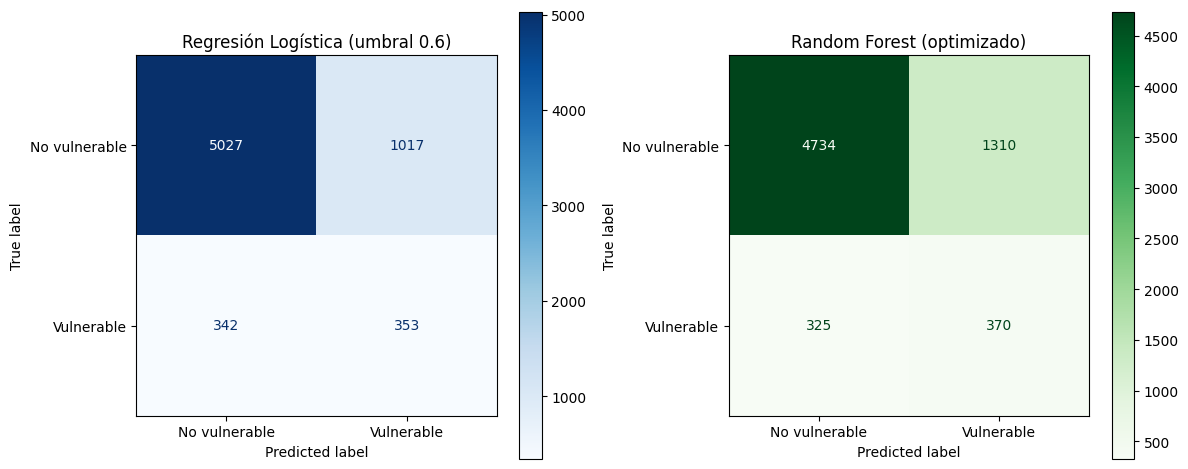

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_logit, display_labels=['No vulnerable','Vulnerable'], ax=axes[0], cmap='Blues'
)
axes[0].set_title('Regresión Logística (umbral 0.6)')

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_rf, display_labels=['No vulnerable','Vulnerable'], ax=axes[1], cmap='Greens'
)
axes[1].set_title('Random Forest (optimizado)')

plt.tight_layout()
plt.show()

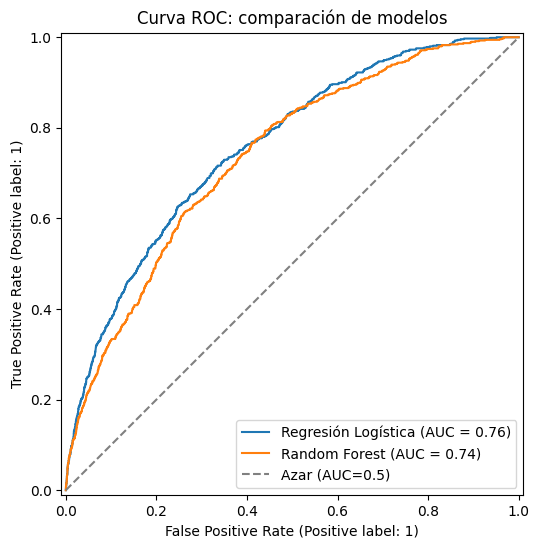

In [16]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7,6))
RocCurveDisplay.from_predictions(y_test, prob_logit, name='Regresión Logística', ax=ax)
RocCurveDisplay.from_predictions(y_test, mejor_rf.predict_proba(X_test)[:,1], name='Random Forest', ax=ax)
ax.plot([0,1],[0,1], linestyle='--', color='gray', label='Azar (AUC=0.5)')
ax.set_title('Curva ROC: comparación de modelos')
ax.legend()
plt.show()

# **Variables más influyentes (interpretabilidad)**

In [17]:
coeficientes = pd.DataFrame({
    'variable': X_train_scaled.columns,
    'coeficiente': modelo_logit.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)

print(coeficientes.head(10))

             variable  coeficiente
17  REGION_LAMBAYEQUE    -1.368821
3   gasto_salud_hogar    -1.350363
24        REGION_PUNO     0.880733
6     REGION_APURIMAC    -0.860762
11       REGION_CUSCO    -0.795954
0        tamano_hogar     0.692742
26       REGION_TACNA     0.596006
7     REGION_AREQUIPA     0.364578
27      REGION_TUMBES    -0.359592
14         REGION_ICA    -0.356445


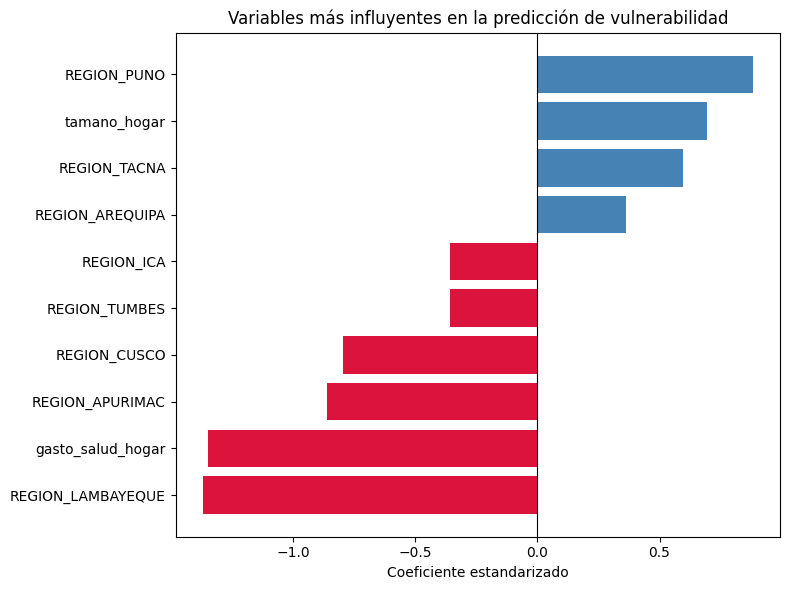

In [18]:
top10 = coeficientes.head(10).sort_values('coeficiente')

plt.figure(figsize=(8,6))
colores = ['crimson' if c < 0 else 'steelblue' for c in top10['coeficiente']]
plt.barh(top10['variable'], top10['coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Variables más influyentes en la predicción de vulnerabilidad')
plt.xlabel('Coeficiente estandarizado')
plt.tight_layout()
plt.show()

# **COMPARACIÓN TERRITORIAL**

In [19]:
# Vulnerabilidad entre La Libertad y el territorio nacional.

# Aplicamos el modelo ya entrenado a TODOS los hogares (no solo al test set)
X_todos = modelo_df_encoded.drop(columns=['vulnerable'])
X_todos_scaled = X_todos.copy()
X_todos_scaled[cols_numericas] = scaler.transform(X_todos[cols_numericas])

prob_todos = modelo_logit.predict_proba(X_todos_scaled)[:, 1]

comparacion = modelo_df[['REGION']].copy()
comparacion['prob_vulnerabilidad_modelo'] = prob_todos

prob_la_libertad = comparacion[comparacion['REGION'] == 'LA LIBERTAD']['prob_vulnerabilidad_modelo'].mean()
prob_nacional = comparacion['prob_vulnerabilidad_modelo'].mean()
prob_resto_regiones = comparacion[comparacion['REGION'] != 'LA LIBERTAD']['prob_vulnerabilidad_modelo'].mean()

print(f"Probabilidad promedio de vulnerabilidad (modelo) — La Libertad:        {prob_la_libertad*100:.1f}%")
print(f"Probabilidad promedio de vulnerabilidad (modelo) — Resto del país:     {prob_resto_regiones*100:.1f}%")
print(f"Probabilidad promedio de vulnerabilidad (modelo) — Promedio nacional:  {prob_nacional*100:.1f}%")

# Ranking completo de las 25 regiones, según lo que el modelo estima
ranking_regional = (
    comparacion.groupby('REGION')['prob_vulnerabilidad_modelo']
    .mean()
    .sort_values(ascending=False)
)
print("\nRanking de regiones según probabilidad promedio de vulnerabilidad (modelo):")
print(ranking_regional.to_string())

Probabilidad promedio de vulnerabilidad (modelo) — La Libertad:        38.0%
Probabilidad promedio de vulnerabilidad (modelo) — Resto del país:     41.7%
Probabilidad promedio de vulnerabilidad (modelo) — Promedio nacional:  41.5%

Ranking de regiones según probabilidad promedio de vulnerabilidad (modelo):
REGION
LORETO           0.696313
UCAYALI          0.619153
PUNO             0.613082
PASCO            0.513160
HUANUCO          0.512011
SAN MARTIN       0.511260
AMAZONAS         0.499220
MADRE DE DIOS    0.491879
CAJAMARCA        0.481411
PIURA            0.479530
AYACUCHO         0.465944
TACNA            0.449221
HUANCAVELICA     0.432061
LA LIBERTAD      0.380176
AREQUIPA         0.377057
TUMBES           0.374086
LIMA             0.373951
CALLAO           0.369066
JUNIN            0.358958
ANCASH           0.354771
MOQUEGUA         0.307529
CUSCO            0.246414
ICA              0.232407
APURIMAC         0.230102
LAMBAYEQUE       0.156519


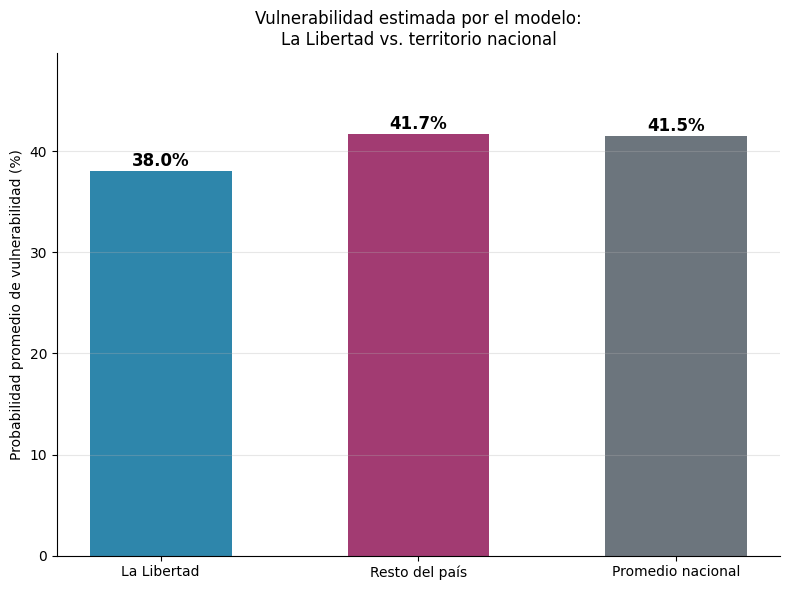

In [20]:
import matplotlib.pyplot as plt

categorias = ['La Libertad', 'Resto del país', 'Promedio nacional']
valores = [prob_la_libertad*100, prob_resto_regiones*100, prob_nacional*100]
colores = ['#2E86AB', '#A23B72', '#6c757d']

fig, ax = plt.subplots(figsize=(8, 6))
barras = ax.bar(categorias, valores, color=colores, width=0.55)

# Etiquetas de valor encima de cada barra
for barra, valor in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 0.5,
             f'{valor:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Probabilidad promedio de vulnerabilidad (%)')
ax.set_title('Vulnerabilidad estimada por el modelo:\nLa Libertad vs. territorio nacional')
ax.set_ylim(0, max(valores) + 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# **Gráfico: evolución del Índice CEPLAN, La Libertad vs. nacional**

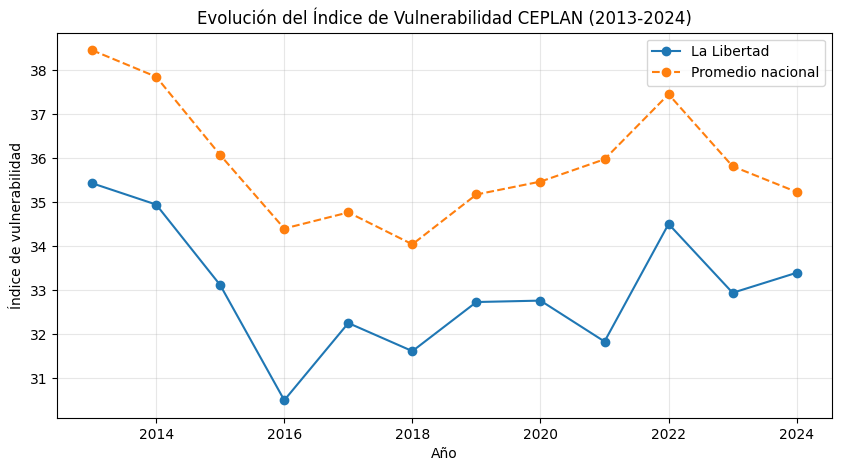

In [ ]:
def normalizar_region(texto):
    import unicodedata
    texto = str(texto).strip().upper()
    return unicodedata.normalize('NFKD', texto).encode('ascii','ignore').decode('ascii')

ceplan = pd.read_excel(f'{RAW}/ceplan/7564628-ceplan-sub-indices-de-vulnerabilidad-2013-2024.xlsx', skiprows=3)
ceplan = ceplan[ceplan['Región'].notna()]
ceplan = ceplan[~ceplan['Región'].astype(str).str.upper().str.contains('PROMEDIO')]
ceplan['REGION_NORM'] = ceplan['Región'].apply(normalizar_region)

anios = list(range(2013, 2025))
fila_lal = ceplan[ceplan['REGION_NORM'] == 'LA LIBERTAD']
promedio_nacional = ceplan[anios].mean()

plt.figure(figsize=(10,5))
plt.plot(anios, fila_lal[anios].values.flatten(), marker='o', label='La Libertad')
plt.plot(anios, promedio_nacional.values, marker='o', linestyle='--', label='Promedio nacional')
plt.title('Evolución del Índice de Vulnerabilidad CEPLAN (2013-2024)')
plt.xlabel('Año'); plt.ylabel('Índice de vulnerabilidad')
plt.legend(); plt.grid(alpha=0.3)
plt.show()